# <a href="https://thetahat.ru/courses/ad">Введение в анализ данных</a>
## Домашнее задание 8. Вероятность


**Правила, <font color="red">прочитайте внимательно</font>:**

1. Общее

     * Выполненную работу **в формате `ipynb`** нужно отправить по ссылке "Сдача ДЗ" на <a href="https://thetahat.ru/courses/ad"><b>странице курса</b></a>. **Работы, присланные иным способом, не принимаются.** Дедлайны указаны в боте и на сайте, они являются строгими.
     
     * Обязательно изучите <a href="https://thetahat.ru/courses/design-hw"><b>руководство по оформлению ДЗ</b></a>. В частности, оно содержит примеры случаев, когда могут быть снижены баллы.
     
     * Обратите внимание на <a href="https://thetahat.ru/courses/ai-rules"><b>правила использования ИИ-инструментов</b></a> при решении домашнего задания.
     
     * Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания (в т.ч. злоупотребление ИИ) всем участникам списывания дается штраф -3 скор-балла к итоговой оценке.**
     
     * Решение теоретических задач оформляйте в markdown-ячейках формате $\LaTeX$. При решении можно использовать ИИ-инструменты только для оформления написанного самостоятельно решения. Например, написать черновик формул и попросить ИИ оформить эти формулы в $\LaTeX$.
     
     * Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
     </br>

2. Правила заполнения ноутбука

     * Запрещается удалять имеющиеся в ноутбуке ячейки, менять местами положения существующих ячеек.
     * Отвечайте на вопросы, а также добавляйте новые ячейки в любом количестве в предложенных местах, которые обозначены `<...>`.
     * Сохраняйте естественный линейный порядок повествования в ноутбуке сверху-вниз. Комментарии к решению пишите в markdown-ячейках.
     * Условия <font color="red"><b>запрещается модифицировать</b></font>.
     * При нарушении данных правил работа может получить 0 баллов.
</br>


**Баллы за задание**

* Задача 1 &mdash; 60 баллов
* Задача 2 &mdash; 40 баллов
* Задача 3 &mdash; 100 баллов

In [247]:
# Bot check

# HW_ID: fpmi_ad8
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [205]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from functools import partial
from typing import List, Dict
from scipy.stats import cauchy, bernoulli

sns.set(style="whitegrid", palette="Set2")

### Ссылки на использование ИИ

Если при решении задач использовался ИИ, укажи здесь публичные ссылки на все чаты с ИИ и поясни, для каких целей он применялся. Обрати внимание на <a href="https://thetahat.ru/courses/ai-rules" target="_top">правила</a>.

**Задача 1**
1. [ссылка](https://chatgpt.com/share/69da3510-11ac-838d-a5d7-8c8a3862c409)



---
### Задача 1.

**При решении данной задачи можно использовать ИИ-инструменты только для построения графиков и оформления документации к коду. Использование ИИ-инструментов для решения контеста запрещено.**

Современные библиотеки для генерации используют алгоритмы вроде PCG64 (Permuted Congruential Generator-64), который достаточно быстро генерирует случайные 64-битные целые числа. Если их отнормировать на максимально возможное число ($2^{64}-1$), мы получим равномерное распределение $U(0, 1)$.

В рамках этой задачи для лучшего понимания взаимосвязей случайных величин мы пойдем другим путем. Будем предполагать, что у нас имеется только симметричная монета, один бросок которой моделирует случайную величину из бернуллиевского распределения с параметром $p = 0.5$.

In [45]:
# Создаем генератор случайных чисел
rng = np.random.default_rng()
# Фиксируем первые два аргумента функции rng.integers (low=0 и high=2)
coin = partial(rng.integers, 0, 2)

Вам предстоит написать собственные генераторы выборок из равномерного, нормального и экспоненциального распределений с заданными параметрами, используя в качестве основы исключительно броски правильной монеты. Совершать броски можно неограниченное количество раз. Тем не менее, поскольку лишние броски увеличивают время генерации, стоит использовать оптимальное количество бросков. За лишнее количество бросков могут быть сняты баллы.

**1.** Напишите функцию **`uniform`** генерации случайных величин из равномерного распределения на отрезке $[0, 1]$ с заданной точностью. Это можно сделать, записав случайную величину $\xi \sim U(0, 1)$ в двоичной системе системе счисления $\xi = 0,\xi_1\xi_2\xi_3...$. Тогда $\xi_i \sim Bern(1/2)$ и независимы в совокупности. Приближение заключается в том, что вместо генерации бесконечного количества $\xi_i$ мы полагаем $\xi = 0,\xi_1\xi_2\xi_3...\xi_n$.

Нужно реализовать функцию `uniform` так, чтобы она могла принимать на вход в качестве параметра `size` как число, так и объект `tuple` любой размерности, и возвращать объект `numpy.array` соответствующей размерности. Например, если `size=(10, 1, 5)`, то функция должна вернуть объект размера $10 \times 1 \times 5$. Аргумент `n_bits` отвечает за число $n$.

Также обратите внимание, что  функцию `coin` можно вызвать только один раз. Для совершения 10 бросков монеты используйте `coin(10)`, это считается одним вызовом функции. При реализации функций генерации нельзя использовать какие-либо циклы, а также функции `np.vectorize`, `np.apply_along_axis`, `np.fromiter` и подобные, это медленно и по сути является циклом. Используйте векторные функции `numpy`. При нарушении этих правил будут сниматься баллы.

In [46]:
def uniform(size: int | tuple = 1, n_bits: int = 50) -> float | np.ndarray:
    """
    Генерирует выборку из непрерывного равномерного распределения U(0, 1).

    Параметры
    ---------
    size: Размерность выходного массива (одно число для вектора или кортеж для тензора).
    n_bits: Количество бросков честной монеты (битов) для аппроксимации одного вещественного числа.

    Возвращает
    ----------
    Сгенерированные значения из равномерного распределения на интервале [0, 1].
    """

    if isinstance(size, int):
      size = (size,)
    return ((2.0 ** (-np.arange(1, n_bits + 1))) * coin(size + (n_bits,))).sum(axis = -1)


Cгенерируйте $200$ независимых случайных величин, постройте график плотности на отрезке $[-0.25, 1.25]$, а также гистограмму по сгенерированным случайным величинам. Для построения графика необходимо брать достаточно большое количество точек сетки.

Text(0, 0.5, 'Плотность')

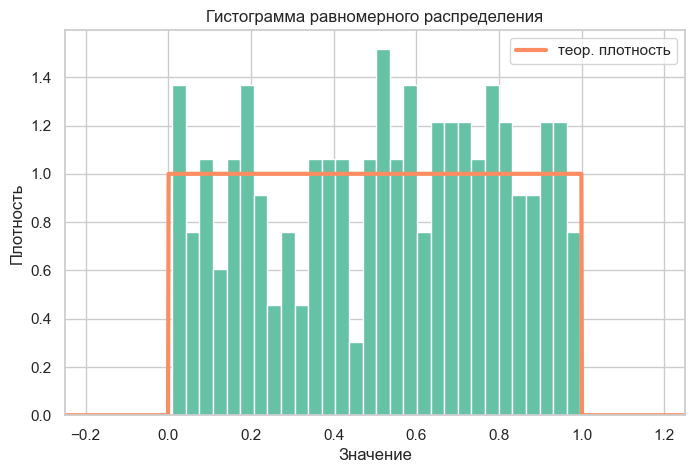

In [225]:
uniform_array = uniform(200)

x_uni = np.linspace(-0.25, 1.25, 1000)
y_uni = ((x_uni >= 0) & (x_uni <= 1)).astype(float)

plt.figure(figsize=(8, 5))

plt.hist(uniform_array, bins=30, density=True)  # добавляем density для нормировки
plt.plot(x_uni, y_uni, linewidth=3, label = "теор. плотность")
plt.xlim(-0.25, 1.25)

plt.title("Гистограмма равномерного распределения")
plt.legend()
plt.xlabel("Значение")
plt.ylabel("Плотность")

Исследуйте, как меняются значения случайных величин в зависимости от `n_bits` в написанной ранее вами функции.

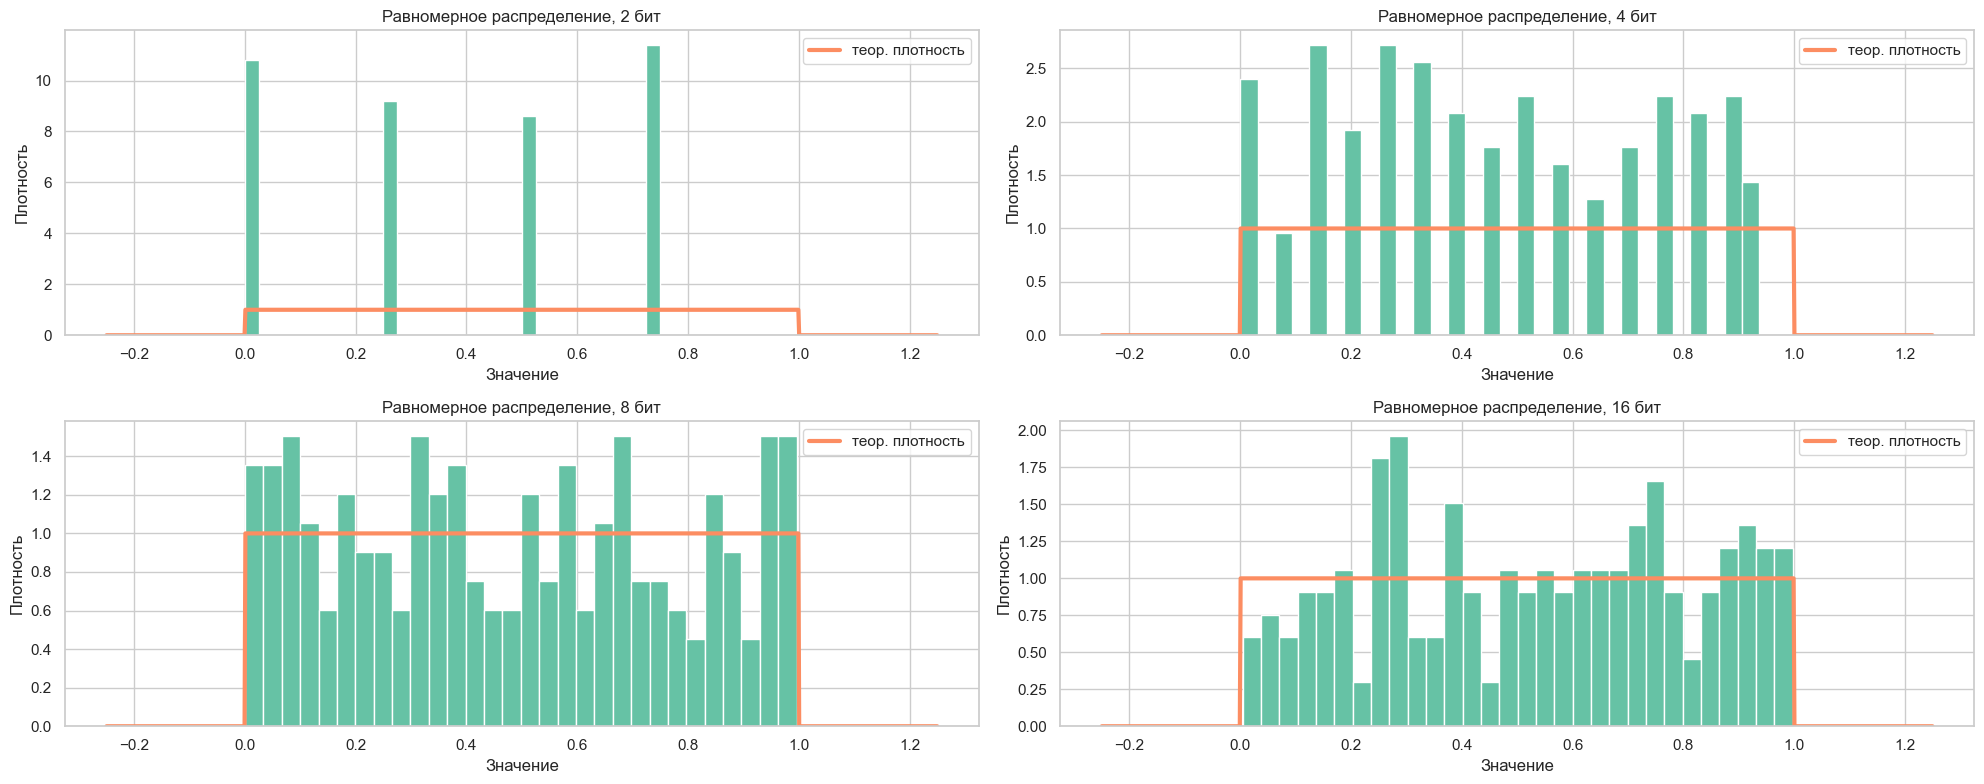

In [232]:
n_bits_arr = [2, 4, 8, 16]

plt.figure(figsize=(20, 8))

for i in range(0, 4):
  plt.subplot(2, 2, i + 1)
  plt.hist(uniform(200, n_bits_arr[i]), bins=30, density=True)
  plt.plot(x_uni, y_uni, linewidth=3, label = "теор. плотность")
  plt.title(f"Равномерное распределение, {n_bits_arr[i]} бит")
  plt.xlabel("Значение")
  plt.ylabel("Плотность")
  plt.legend()
plt.tight_layout()

**2.** Напишите функцию **`normal`** генерации случайных величин в количестве `size` штук из распределения $\mathcal{N}(loc, scale^2)$ с помощью преобразования Бокса-Мюллера. 

Реализация должна быть без циклов. В качестве параметра `size` может быть как число, так и объект `tuple` любой размерности. Можно использовать реализованную ранее функцию `uniform`.

При реализации `normal` допускается использовать количество бросков монеты чуть больше оптимального с целью упрощения кода. А именно, для генерации выборки размера $n$ можно использовать броски монет не более того количества, которое требуется для оптимальной генерации выборки размера $n+1$.

In [233]:
def normal(
    size: int | tuple = 1, loc: float = 0.0, scale: float = 1.0, n_bits: int = 50
) -> float | np.ndarray:
    """
    Генерирует выборку из нормального распределения N(loc, scale^2).

    Параметры
    ---------
    size: Размерность выходного массива (одно число для вектора или кортеж для тензора).
    loc: Математическое ожидание распределения.
    scale: Стандартное отклонение распределения (должно быть > 0).
    n_bits: Количество бросков честной монеты (битов) для базовой генерации U(0, 1).

    Возвращает
    ----------
    Сгенерированные значения из нормального распределения.
    """

    if isinstance(size, int):
      size = (size,)
    
    N = np.prod(size)
    m = int((N + 1) // 2)

    # защита от log(0)
    u1 = uniform(m, n_bits)
    u1 = np.clip(u1, 1e-12, 1)

    R = np.sqrt(-2 * np.log(u1))
    F = 2 * np.pi * uniform(m, n_bits)
    Z_1 = R * np.cos(F)
    Z_2 = R * np.sin(F)
    z = np.concatenate([Z_1, Z_2])[:N]

    return (loc + scale * z).reshape(size)

    

Cгенерируйте $200$ независимых случайных величин, постройте график плотности на отрезке $[-3, 3]$, а также гистограмму по сгенерированным случайным величинам.

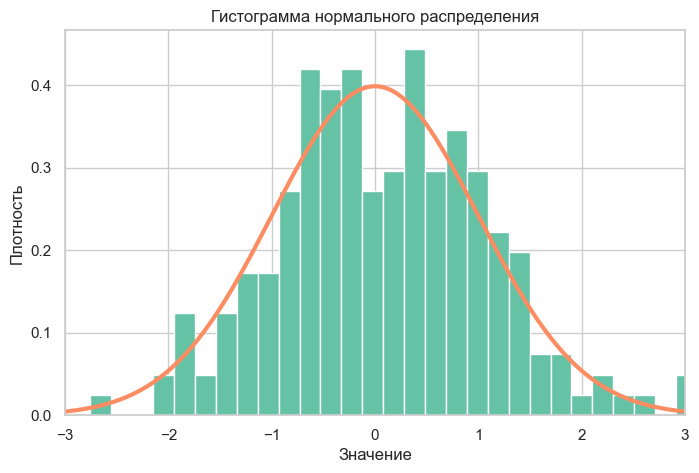

In [237]:
normal_array = normal(200)

x_nom = np.linspace(-3, 3, 1000)
y_nom = (1 / np.sqrt((2 * np.pi)) * np.exp((-x_nom ** 2) / 2))

plt.figure(figsize=(8, 5))

plt.hist(normal_array, bins=30, density=True)
plt.plot(x_nom, y_nom, linewidth=3)
plt.xlim(-3, 3)

plt.title("Гистограмма нормального распределения")
plt.xlabel("Значение")
plt.ylabel("Плотность")

plt.show()

**3.** Вы уже научились генерировать выборку из равномерного распределения. Напишите функцию **`expon`** генерации выборки из экспоненциального распределения, используя задачу из теории вероятностей:

*Если $\xi$ — случайная величина, имеющая абсолютно непрерывное распределение, и $F$ — ее функция распределения, то случайная величина $F(\xi)$ имеет равномерное распределение на $[0, 1]$*.

In [105]:
def expon(size: int | tuple = 1, lambd: float = 1.0, n_bits: int = 50) -> float | np.ndarray:
    """
    Генерирует выборку из экспоненциального распределения Exp(lambd).

    Параметры
    ---------
    size: Размерность выходного массива (одно число для вектора или кортеж для тензора).
    lambd: Параметр интенсивности (должно быть > 0).
    n_bits: Количество бросков честной монеты (битов) для базовой генерации U(0, 1).

    Возвращает
    ----------
    Сгенерированные значения из экспоненциального распределения.
    """
    return -np.log(1 - np.clip(uniform(size, n_bits), 1e-12, 1 - 1e-12)) / lambd

Для $Exp(1)$ сгенерируйте выборку размера 200 и постройте график плотности этого распределения на отрезке $[-0.5, 5]$.

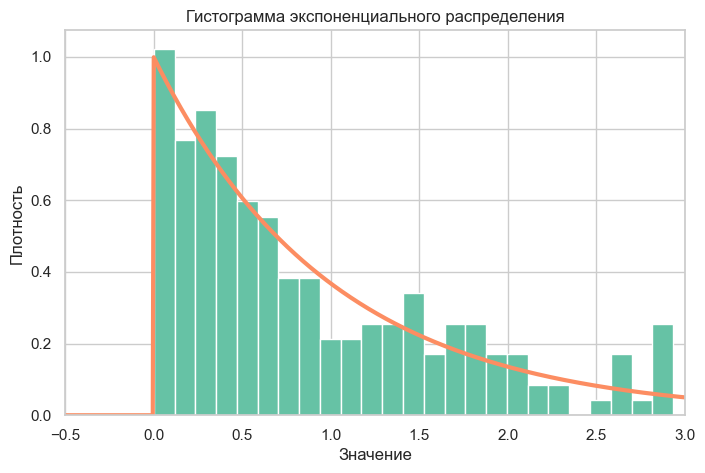

In [238]:
exp_array = expon(200, 1)

x_exp = np.linspace(-0.5, 5, 1000)
y_exp = np.exp(-x_exp) * (x_exp >= 0)

plt.figure(figsize=(8, 5))

plt.hist(exp_array, bins=40, density=True)  # добавляем density для нормировки
plt.plot(x_exp, y_exp, linewidth=3)
plt.xlim(-0.5, 3)

plt.title("Гистограмма экспоненциального распределения")
plt.xlabel("Значение")
plt.ylabel("Плотность")

plt.show()

**4. Выводы:**

1) На гистограммах равномерного распределения видно, что при увелечении количества битов, распределение становится менее детерминированным, в том смысле что велечины могут принмать больше значений из-за этого гистаграмма всё лучше приближает теоретическое равномерное распределение на отрезке [0,1].
2) При больших n_bits визуальные отличия становятся слабыми, потому что распределение уже хорошо аппроксимирует непрерывное равномерное.
3) В целом для выборка из 200  значений является довольно маленькой, поэтому гистограмма заметно меняется от одной генерации к другой.

---

### Задача 2.

Рассмотрим <a target="_black" href="https://ru.wikipedia.org/wiki/Распределение_Коши">распределение Коши</a> с плотностью
$$p(x) = \frac{1}{\pi(1+x^2)}$$
для $x\in\mathbb{R}$, которое известно своими <a target="_black" href="https://en.wikipedia.org/wiki/Heavy-tailed_distribution">тяжелыми хвостами</a>. Иначе говоря, плотность убывает медленно при $x \to \infty$ (точное определение может различаться для разных источников). Сравните, например, с нормальным или экспоненциальным распределениями. В частности, из-за этого у распределения Коши даже не существует математического ожидания.

За распределение Коши отвечает класс <a target="_black" href="https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.cauchy.html">`scipy.stats.cauchy`</a>.

**1.** Визуализируйте на одном графики плотности нормального распределения и распределения Коши. Что можно сказать?

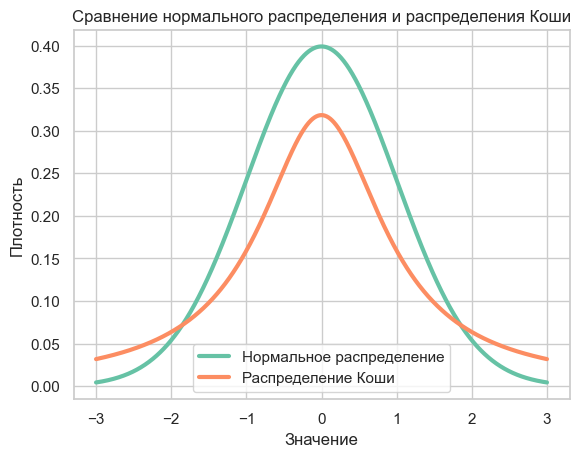

In [239]:
plt.plot(x_nom, y_nom, linewidth=3, label="Нормальное распределение")
x_cauchy = x_nom

y_cauchy = 1 / (np.pi * (1 + x_cauchy**2))
plt.plot(x_cauchy, y_cauchy, linewidth=3, label="Распределение Коши")

plt.title("Сравнение нормального распределения и распределения Коши")
plt.xlabel("Значение")
plt.ylabel("Плотность")
plt.legend()


**2.** Повторите эксперимент с <a href="https://thetahat.ru/courses/ad/main/9/2_lln" target="_top">занятия</a> про закон больших чисел для распределения Коши. Выполняется ли закон?

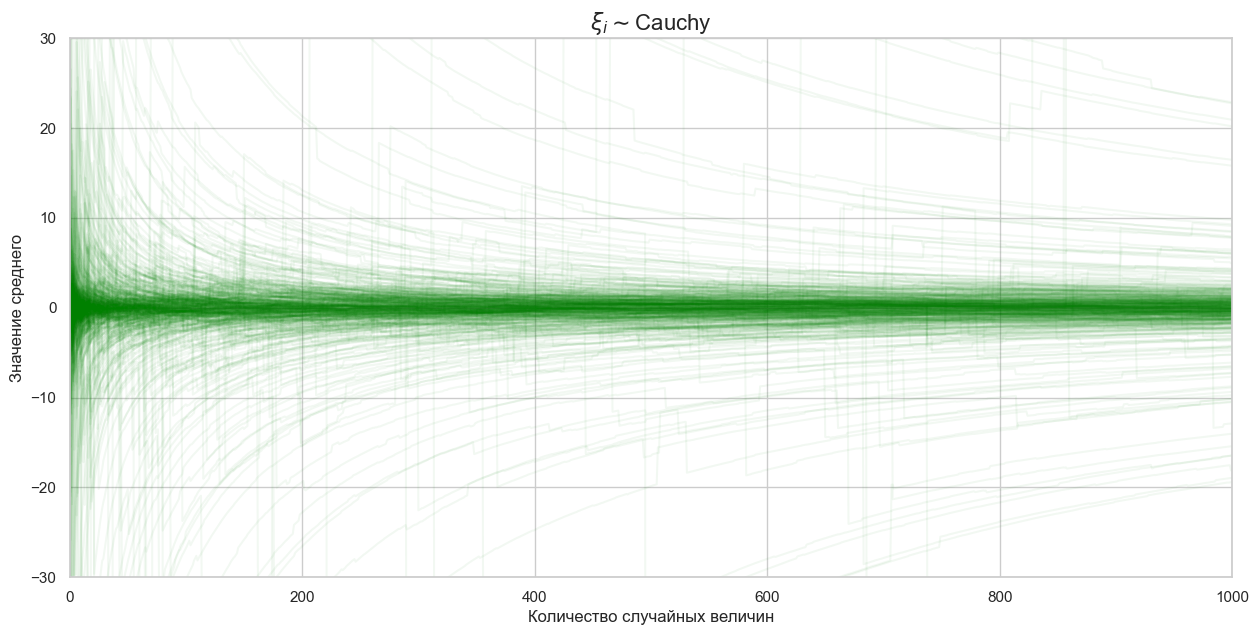

In [245]:
# Генерация выборки и вычисление средних
samples = cauchy.rvs(size=(500, 1000))
cum_means = samples.cumsum(axis=1) / (np.arange(1000) + 1)

# График
plt.figure(figsize=(15, 7))
for i in range(500):
    plt.plot(np.arange(1000) + 1, cum_means[i], color="green", alpha=0.05)
plt.title("$\\xi_i \\sim $" + "Cauchy", fontsize=16)
plt.xlabel("Количество случайных величин")
plt.ylabel("Значение среднего")
plt.xlim((0, 1000))
plt.ylim(-30, 30)
plt.show()

**3.** Аналогичным образом проведите эксперимент по изучению сходимости *выборочной* медианы при увеличении размера выборки. Медиану по выборке можно посчитать с помощью <a target="_blank" href="https://numpy.org/doc/stable/reference/generated/numpy.median.html">`np.median`</a>.

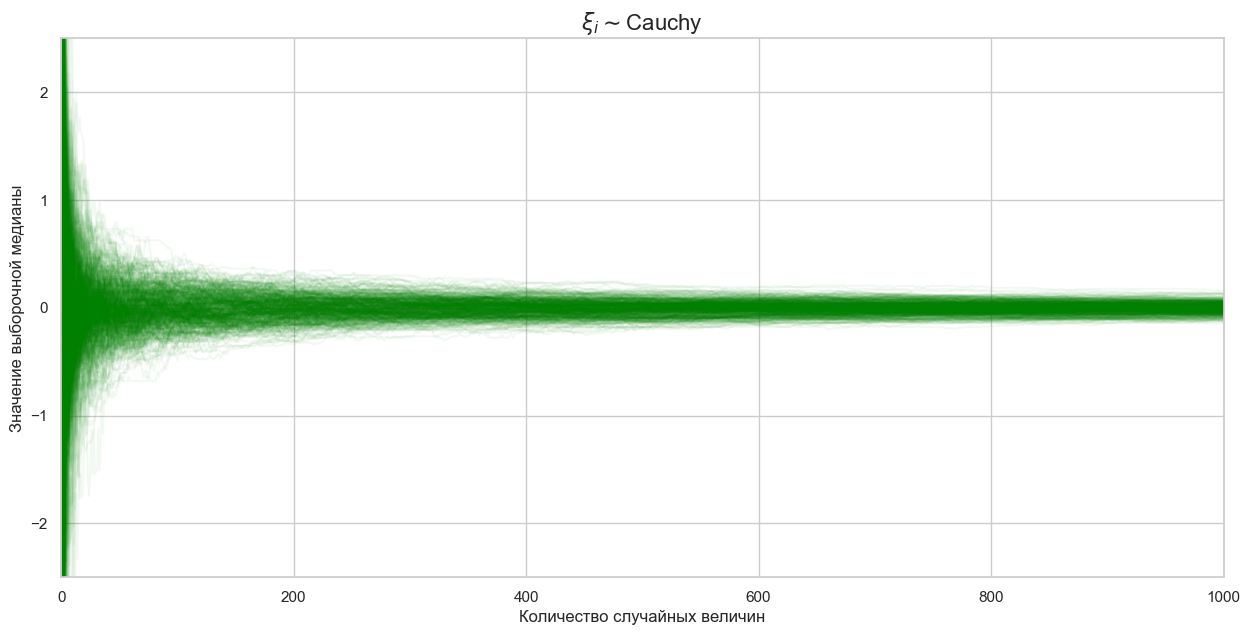

In [246]:
# Генерация выборки и вычисление средних
cum_medians = np.array([
    [np.median(row[:k]) for k in range(1, row.size + 1)]
    for row in samples
])

# График
plt.figure(figsize=(15, 7))
for i in range(500):
    plt.plot(np.arange(1000) + 1, cum_medians[i], color="green", alpha=0.05)
plt.title("$\\xi_i \\sim $" + "Cauchy", fontsize=16)
plt.xlabel("Количество случайных величин")
plt.ylabel("Значение выборочной медианы")
plt.xlim((0, 1000))
plt.ylim(-2.5, 2.5)
plt.show()

**4. Вывод:**

Для распределения Коши выборочное среднее не сходится к фиксированному значению, поскольку математическое ожидание этого распределения не существует, а значит закон больших чисел не работает. C другой стороны значение медианы как раз сходится к 0, то есть имеет смысл рассматривать именно медиану.

---
### Задача 3.

Перед выполнением этой задачи настоятельно рекомендуется посмотреть <a href="https://thetahat.ru/courses/ad/main/9/2_lln" target="_top">ноутбук</a> с лекции про закон больших чисел.

На практике не редко возникает вопрос &mdash; **сколько времени потребуется на сбор данных, чтобы оценить среднее с достаточной точностью**. Для ответа на этот вопрос можно использовать различные теоретические оценки, в частности, неравенство Чебышева.

Другой способ &mdash; смоделировать большое количество выборок. Предположим, что мы сгенерировали $K$ выборок размера $n$ каждая, и $M_{nj}$ &mdash; *выборочное* среднее элементов в $j$-й выборке. Пусть математическое ожидание равно $a$, будем считать его известным в данной задаче. Тогда в качестве меры отклонения от среднего *среднее значение модуля отклонения от $a$*, то есть
$$F(n) = \frac{1}{K}\sum\limits_{j=1}^{K} \left|M_{nj} - a \right|,$$

**1.** Рассмотрим распределения $Bern(a)$ для $a=0.5$. Пусть для нас допустимо отклонение на 0.02, иначе говоря при *истинном* среднем 0.5 мы считаем достаточно точными значения *выборочного* среднего от 0.48 до 0.52. Тогда в качестве *приближения* необходимого размера выборок можно взять наименьшее значение $n$, при котором $F(n) \leqslant 0.02$.

Реализуйте данный эксперимент для $K=500$ и найдите значение $n$. Визуализируйте зависимость $F(n)$ от $n$ в обычном и логарифмическом масштабах (по тем осям, по которым это имеет смысл).

Для реализации без циклов стоит генерировать достаточно большие выборки и использовать функцию `np.where`.

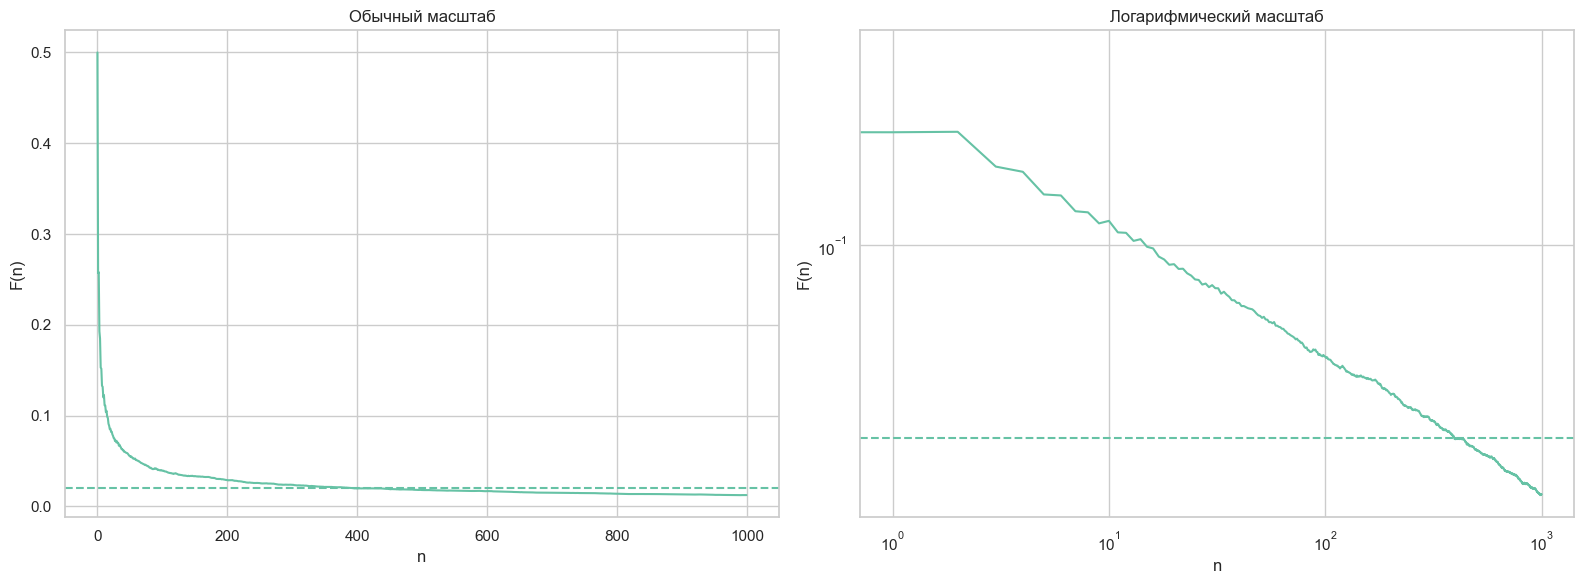

n_need = 396


In [199]:
samples_bernoulli = bernoulli.rvs(0.5, size=(500, 1000))
cum_means = samples_bernoulli.cumsum(axis=1) / (np.arange(1000) + 1)
F_y = np.abs(cum_means - 0.5).mean(axis=0)
n_need = np.where(F_y <= 0.02)[0][0] + 1


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(1000)

axes[0].plot(x, F_y)
axes[0].axhline(0.02, linestyle='--')
axes[0].set_xlabel('n')
axes[0].set_ylabel('F(n)')
axes[0].set_title('Обычный масштаб')

axes[1].plot(x, F_y)
axes[1].axhline(0.02, linestyle='--')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('n')
axes[1].set_ylabel('F(n)')
axes[1].set_title('Логарифмический масштаб')


plt.tight_layout()
plt.show()

print("n_need =", n_need)


**2.** Повторите эксперимент из пункта 1 для значений $a$ от 0.05 до 0.95 с шагом 0.05. Визуализируйте зависимость необходимого размера выборки $n$ от значения $a$.

При реализации можно сделать цикл по значениям $a$.

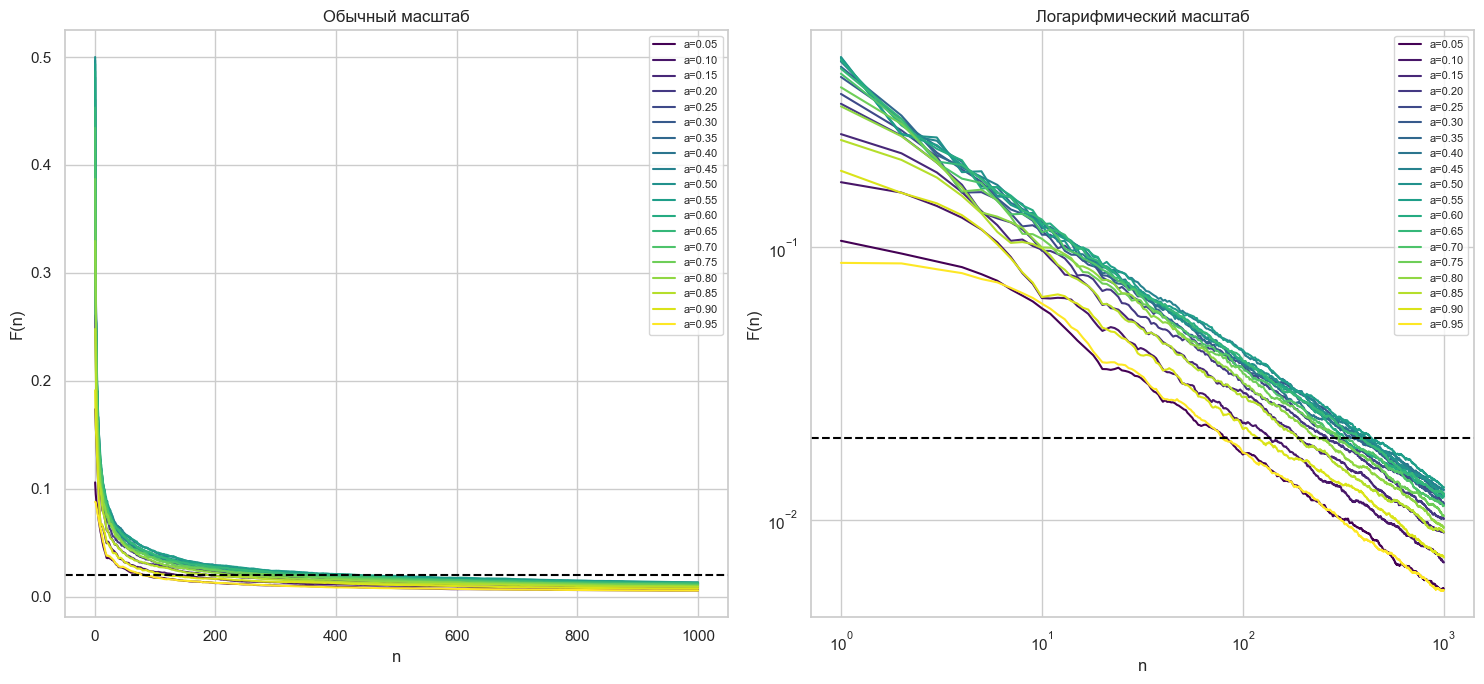

In [193]:
a_arr = np.arange(0.05, 1.00, 0.05)
x = np.arange(1, 1001)

colors = plt.cm.viridis(np.linspace(0, 1, len(a_arr)))

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

for i, a in enumerate(a_arr):
    samples_bernoulli = bernoulli.rvs(a, size=(500, 1000))
    cum_means = samples_bernoulli.cumsum(axis=1) / x
    F_y = np.abs(cum_means - a).mean(axis=0)

    axes[0].plot(x, F_y, color=colors[i], label=f'a={a:.2f}')
    axes[1].plot(x, F_y, color=colors[i], label=f'a={a:.2f}')

axes[0].axhline(0.02, linestyle='--', color='black')
axes[0].set_xlabel('n')
axes[0].set_ylabel('F(n)')
axes[0].set_title('Обычный масштаб')
axes[0].legend(fontsize=8)

axes[1].axhline(0.02, linestyle='--', color='black')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('n')
axes[1].set_ylabel('F(n)')
axes[1].set_title('Логарифмический масштаб')
axes[1].legend(fontsize=8)



plt.tight_layout()
plt.show()
  

/var/folders/g0/kzkhxj_52wd1b0trslf_kmd80000gn/T/ipykernel_3252/633945540.py:5: RuntimeWarning: divide by zero encountered in divide
  cum_means = samples_bernoulli.cumsum(axis=1) / x
/var/folders/g0/kzkhxj_52wd1b0trslf_kmd80000gn/T/ipykernel_3252/633945540.py:5: RuntimeWarning: invalid value encountered in divide
  cum_means = samples_bernoulli.cumsum(axis=1) / x


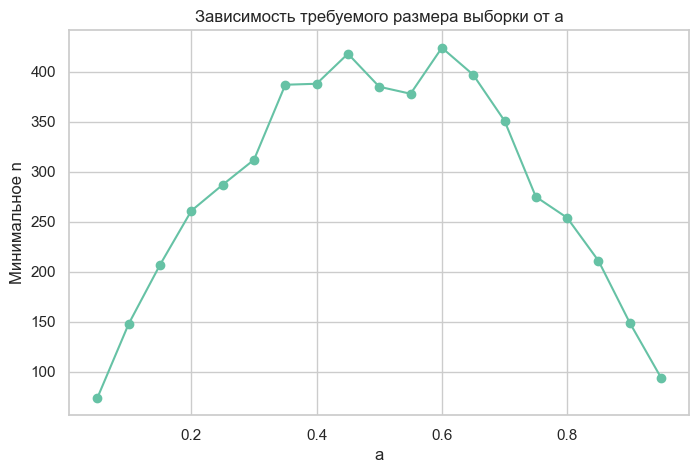

In [203]:
n_arr = []

for a in a_arr:
    samples_bernoulli = bernoulli.rvs(a, size=(500, 1000))
    cum_means = samples_bernoulli.cumsum(axis=1) / x
    F_y = np.abs(cum_means - a).mean(axis=0)

    idx = np.where(F_y <= 0.02)[0]
    n_need = idx[0] + 1 if len(idx) > 0 else np.nan
    n_arr.append(n_need)

plt.figure(figsize=(8, 5))
plt.plot(a_arr, n_arr, marker='o')
plt.xlabel('a')
plt.ylabel('Минимальное n')
plt.title('Зависимость требуемого размера выборки от a')
plt.show()

**3.** В теории часто предполагается независимость элементов выборки, однако, на практике это не всегда так. Исследуем, насколько это влияет на сходимость средних. Повторите эксперимент пункта 1, используя вместо выборки генерацию марковской цепи на значениях 0 и 1 с матрицей переходных вероятностей
$$
\begin{pmatrix}
p & 1-p \\
1-p & p
\end{pmatrix}.
$$

При $p=1/2$ мы получаем генерацию выборки из независимых случайных величин $Bern(1/2)$. При других значениях $p$ мы также получаем случайные величины из $Bern(1/2)$, но они уже зависимы друг с другом.

Проведите эксперимент для значений $p$ от 0.05 до 0.95 с шагом 0.05. Визуализируйте зависимость необходимого размера выборки $n$ от значения $p$.

In [208]:
def generate_markov_chain(
    trans_matrix: list[list[float]],
    start_state: str,
    size: int,
    state_codes: Dict[str, int],
    states: List[str],
) -> List[str]:
    """
    Генерирует последовательность состояний цепи Маркова заданной длины.

    Параметры:
    ----------
    trans_matrix : np.ndarray
        Матрица переходных вероятностей (размер N x N, где N - количество состояний)
    start_state : str
        Начальное состояние цепи
    size : int
        Длина генерируемой последовательности
    state_codes : Dict[str, int]
        Словарь соответствия состояний и их индексов в матрице
    states : List[str]
        Список всех возможных состояний

    Возвращает:
    -----------
    List[str]
        Сгенерированная последовательность состояний
    """
    chain = [start_state]
    for _ in range(size - 1):
        current_state_idx = state_codes[chain[-1]]
        next_state_probs = trans_matrix[current_state_idx]
        next_state = np.random.choice(states, p=next_state_probs)
        chain.append(next_state)
    return chain

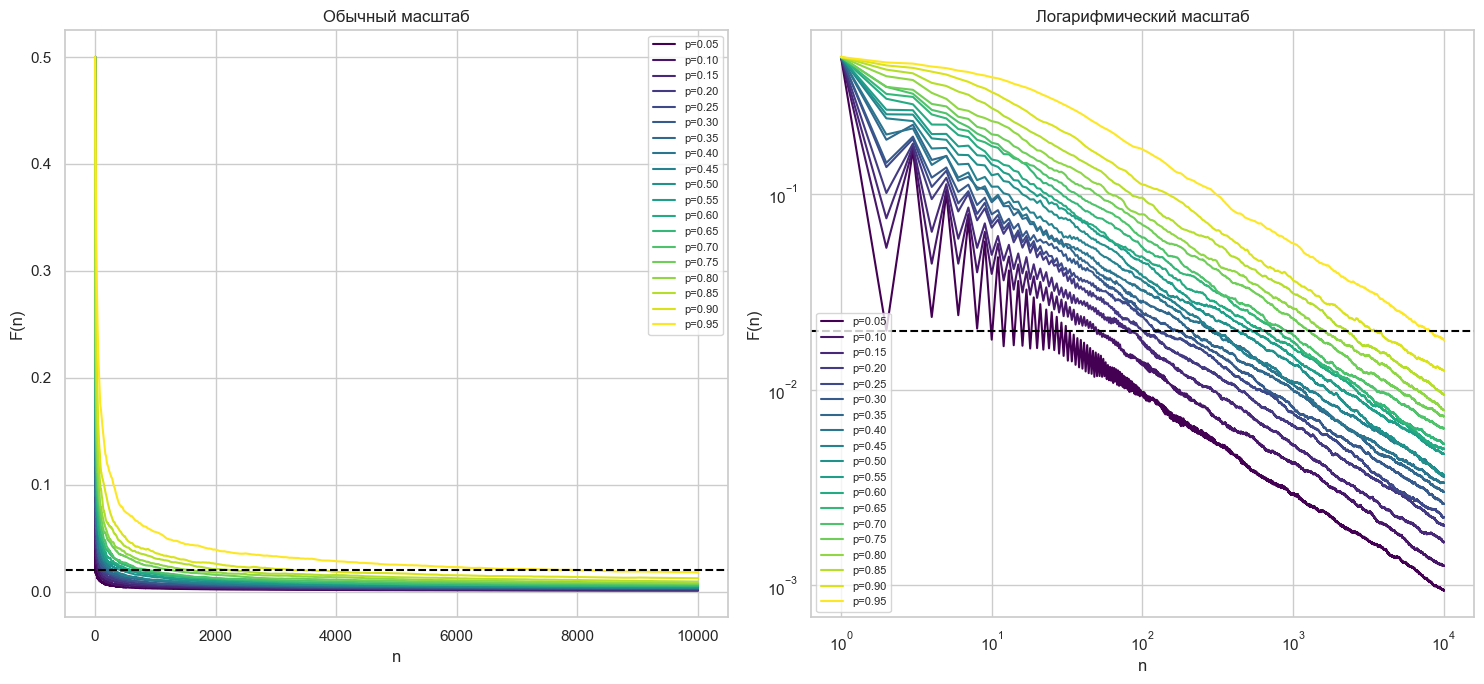

In [243]:
p_arr = np.arange(0.05, 1.00, 0.05)
x = np.arange(1, 10001)

colors = plt.cm.viridis(np.linspace(0, 1, len(p_arr)))
# Список событий
states = [0, 1]
state_codes = {0: 0, 1: 1}

n_markov = []
fig, axes = plt.subplots(1, 2, figsize=(15, 7))


for i, p in enumerate(p_arr):

    transition = [[p, 1 - p], [1 - p, p]]
    chains = np.array([
        generate_markov_chain(transition, np.random.choice(states), 10000, state_codes, states)
        for j in range(0, 500)
    ])
    cum_markov = chains.cumsum(axis=1) / x
    F_y = np.abs(cum_markov - 0.5).mean(axis=0)

    idx = np.where(F_y <= 0.02)[0]
    n_need = idx[0] + 1 if len(idx) > 0 else np.nan
    n_markov.append(n_need)

    axes[0].plot(x, F_y, color=colors[i], label=f'p={p:.2f}')
    axes[1].plot(x, F_y, color=colors[i], label=f'p={p:.2f}')

axes[0].axhline(0.02, linestyle='--', color='black')
axes[0].set_xlabel('n')
axes[0].set_ylabel('F(n)')
axes[0].set_title('Обычный масштаб')
axes[0].legend(fontsize=8)

axes[1].axhline(0.02, linestyle='--', color='black')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('n')
axes[1].set_ylabel('F(n)')
axes[1].set_title('Логарифмический масштаб')
axes[1].legend(fontsize=8)



plt.tight_layout()
plt.show()

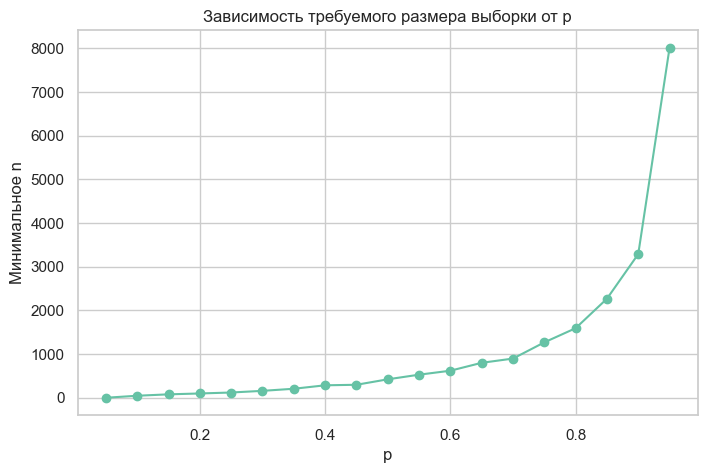

In [244]:
plt.figure(figsize=(8, 5))
plt.plot(p_arr, n_markov, marker='o')
plt.xlabel('p')
plt.ylabel('Минимальное n')
plt.title('Зависимость требуемого размера выборки от p')
plt.show()

**4. Выводы:**

1) В случае с меняющимся параметром a, зависимость требуеього мнимального n является ппримерно симметричный функцией отноститльно a = 0.5. .Это естественно, так как распределения Bern(a) и Bern(1-a) зеркальны друг другу, а величина $F(n) = \frac{1}{K}\sum\limits_{j=1}^{K} \left|M_{nj} - a \right|,$ использует модуль отклонения от истинного среднего. Поэтому случаи a и 1−a дают близкое поведение. Кроме того, на графике с логорифмическими осями зависимость получилась линейной, это значит что F может описыватьися степенной зависимостью от n.
2) При увеличении параметра p требуемое минимальное n монотонно возрастает. Особенно быстро рост наблюдается при p, близких к 1. Это согласуется с тем чтот при p, стремящихся к 1, рост становится особенно резким, что связано с усилением зависимости между соседними состояниями: цепь дольше остаётся в текущем состоянии, а значит среднее стабилизируется медленнее.

---
© 2026 команда <a href="https://thetahat.ru/">ThetaHat</a> для ВвАД